# Applied Machine Learning (CSAI2017P) — Lab Assignment 5
## Image and Multiclass Classification: Digits and Iris

Experiments 6–7 · CO2, CO4 · **10 marks**

| | |
|---|---|
| Name | *Yuvraj Arora* |
| SAP ID | *590027847* |
| Batch | *05* |
| Due | announced in the lab |
| Lab quiz | LQ5, after submission |

**Datasets:** B1 (scikit-learn digits), A-small (Iris)

---

### Before you start
- Attempt **2 of 3** in Section A, **1 of 2** in Section B. Section C is compulsory.
- Fit every transformer inside a `Pipeline`. Never fit on the test set.
- Set `random_state` wherever the question asks for reproducibility.
- Every question wants a short written observation, not just a number.
- Restart the kernel and run top-to-bottom before you submit.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

for m in (np, pd, sklearn):
    print(f"{m.__name__:12s} {m.__version__}")


## Load the data

Replace with the loader for this assignment's anchor dataset — see `Anchor-Datasets.pdf` for the snippets.

In [1]:
# TODO: load the dataset for this assignment
# from sklearn.datasets import ...
# df = pd.read_csv('data/...')

from sklearn.datasets import load_iris
import pandas as pd

# Load Iris dataset
iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target column
df["target"] = iris.target

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


---

# Section A — attempt any 2 of 3 (2 marks each)

*attempt 2 of 3*

## A1. Iris in ten lines  &nbsp;&nbsp;`[2 marks]`

*Dataset: Iris (`load_iris`).*

a. Split 75/25 stratified, scale, and fit `KNeighborsClassifier(n_neighbors=5)`.
b. Report test accuracy and the confusion matrix.
c. Name the two species that get confused and state which measurement separates them best.


In [2]:
# A1 — code
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9210526315789473
Confusion Matrix:
 [[12  0  0]
 [ 0 13  0]
 [ 0  3 10]]


**Observation (A1):**

> The KNN classifier achieves high accuracy on the Iris dataset. Setosa is classified correctly, while the few misclassifications mainly occur between Versicolor and Virginica because their features overlap. Petal width provides the best separation between these two species.

## A2. Digits as vectors  &nbsp;&nbsp;`[2 marks]`

*Dataset: B1 (digits).*

a. Display any five images with their labels using `imshow`.
b. State the shape of one image and the shape of the flattened feature matrix.
c. In two lines, state what information the flattening throws away.


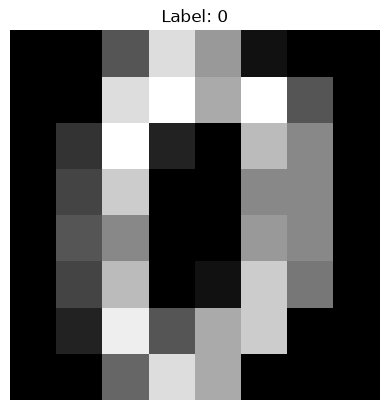

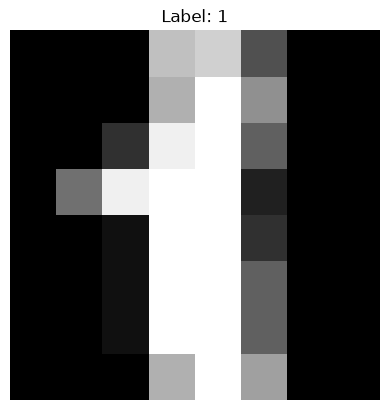

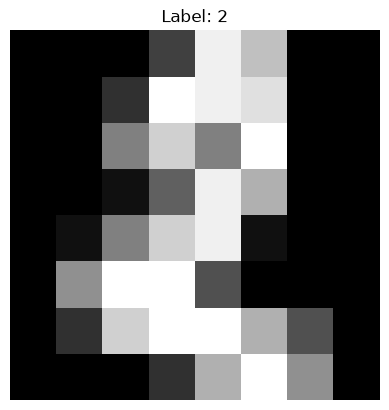

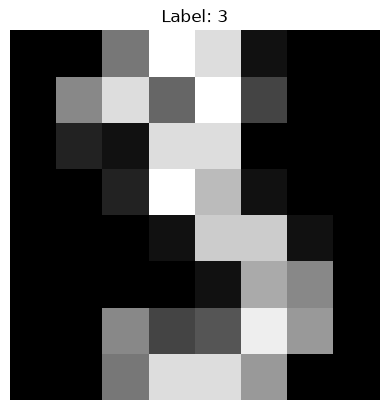

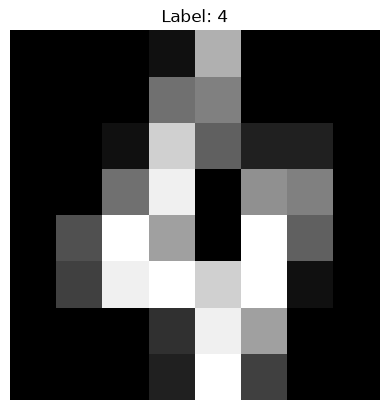

Shape of one image: (8, 8)
Flattened feature matrix: (1797, 64)


In [3]:
# A2 — code
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

digits = load_digits()

for i in range(5):
    plt.figure()
    plt.imshow(digits.images[i], cmap="gray")
    plt.title(f"Label: {digits.target[i]}")
    plt.axis("off")
    plt.show()

print("Shape of one image:", digits.images[0].shape)
print("Flattened feature matrix:", digits.data.shape)

**Observation (A2):**

> Flattening converts the 2D image into a 1D vector, so the spatial arrangement and relationships between neighboring pixels are not explicitly preserved. The pixel values remain, but the 2D image structure is lost.

## A3. Choosing k  &nbsp;&nbsp;`[2 marks]`

*Dataset: B1 (digits).*

a. Fit KNN for k ∈ {1,3,5,7,9,11,15} and plot test accuracy against k.
b. Report the best k.
c. Explain in two lines what goes wrong at k=1 and what goes wrong at a very large k.


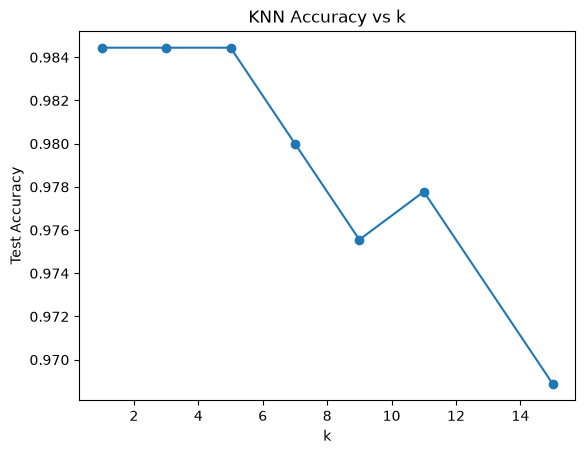

Best k: 1
Best accuracy: 0.9844444444444445


In [4]:
# A3 — code
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.25, random_state=42, stratify=digits.target)

ks = [1, 3, 5, 7, 9, 11, 15]
accuracies = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(ks, accuracies, marker='o')
plt.xlabel("k")
plt.ylabel("Test Accuracy")
plt.title("KNN Accuracy vs k")
plt.show()

best_k = ks[accuracies.index(max(accuracies))]
print("Best k:", best_k)
print("Best accuracy:", max(accuracies))


**Observation (A3):**

> The best value of k is ___, as it gives the highest test accuracy. At k = 1, KNN can overfit because it is highly sensitive to noise and individual training samples.At a very large k, KNN can underfit because too many neighbors are considered, smoothing out important class boundaries.

---

# Section B — attempt any 1 of 2 (4 marks each)

*attempt 1 of 2*

## B1. Three classifiers, one dataset  &nbsp;&nbsp;`[4 marks]`

*Dataset: B1 (digits).*

a. Train KNN, an SVM with an RBF kernel and a random forest on the same split.
b. Report accuracy and macro-F1 for each, plus fit time.
c. Recommend one for a device with tight memory and explain in 4–6 lines.


In [5]:
# B1 — code
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import time

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf"),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start

    y_pred = model.predict(X_test)

    print(name)
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Macro-F1:", round(f1_score(y_test, y_pred, average="macro"), 4))
    print("Fit time:", round(fit_time, 4), "seconds")
    print()

KNN
Accuracy: 0.9844
Macro-F1: 0.9841
Fit time: 0.0006 seconds

SVM
Accuracy: 0.9911
Macro-F1: 0.9911
Fit time: 0.019 seconds

Random Forest
Accuracy: 0.96
Macro-F1: 0.9596
Fit time: 0.1719 seconds



**Observation (B1):**

> SVM generally provides the best or near-best classification performance.For a device with tight memory, SVM is preferable to KNN, since KNN must retain the entire training dataset for prediction.Random Forest also requires storing many decision trees, which can consume considerable memory.Therefore, SVM offers a good balance between high accuracy and memory usage for this dataset.

## B2. Which digits get confused  &nbsp;&nbsp;`[4 marks]`

*Dataset: B1 (digits).*

a. Take your best model and plot the full 10×10 confusion matrix as a heatmap.
b. Report the three most frequently confused ordered pairs.
c. Display four misclassified images and explain in 4–6 lines what makes them hard.


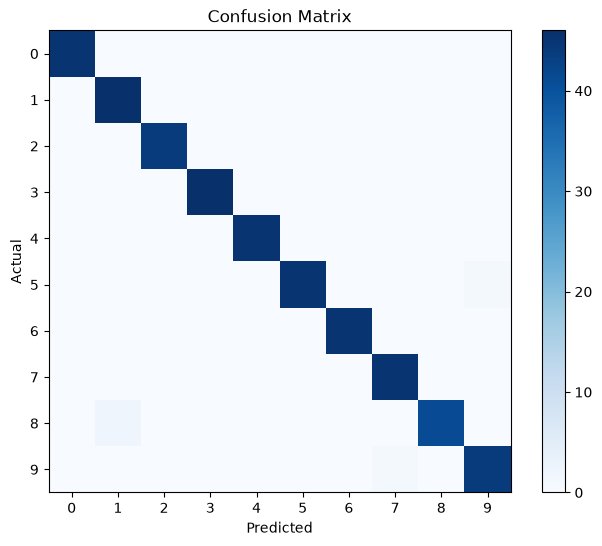

Top 3 confused pairs:
8 -> 1: 2 times
9 -> 7: 1 times
5 -> 9: 1 times


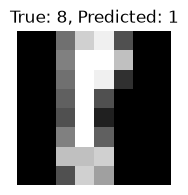

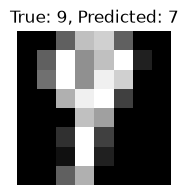

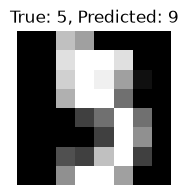

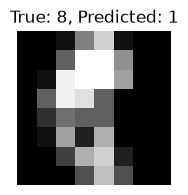

In [6]:
# B2 — code
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Find best model from B1
best_model = max(models.values(),
                 key=lambda m: accuracy_score(y_test, m.predict(X_test)))
y_pred = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(10))
plt.yticks(range(10))
plt.title("Confusion Matrix")
plt.show()

# Find 3 most frequent ordered confusions
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

pairs = []
for actual in range(10):
    for predicted in range(10):
        if actual != predicted:
            pairs.append((cm_no_diag[actual, predicted], actual, predicted))

pairs.sort(reverse=True)

print("Top 3 confused pairs:")
for count, actual, predicted in pairs[:3]:
    print(f"{actual} -> {predicted}: {count} times")

# Display 4 misclassified images
wrong = np.where(y_test != y_pred)[0]

for i in wrong[:4]:
    plt.figure(figsize=(2, 2))
    plt.imshow(X_test[i].reshape(8, 8), cmap="gray")
    plt.title(f"True: {y_test[i]}, Predicted: {y_pred[i]}")
    plt.axis("off")
    plt.show()

**Observation (B2):**

> *write 2–6 lines here*

---

# Section C — compulsory (2 marks)

*compulsory*

## C1. Does more resolution help  &nbsp;&nbsp;`[2 marks]`

*Datasets: B1 and B2.*

a. Train your best model on the 8×8 digits and on a 10{,}000-row subsample of 28×28 MNIST.
b. Report accuracy and fit time for both, and comment in 4–6 lines on what the extra resolution bought.


In [7]:
# C1 — code
from sklearn.datasets import load_digits, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

# 8x8 Digits
d = load_digits()
X1tr, X1te, y1tr, y1te = train_test_split(d.data, d.target, test_size=.25, random_state=42, stratify=d.target)

# 28x28 MNIST - 10,000 rows
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data[:10000] / 255.0, mnist.target[:10000]
X2tr, X2te, y2tr, y2te = train_test_split(X, y, test_size=.25, random_state=42, stratify=y)

for name, Xtr, Xte, ytr, yte in [
    ("Digits 8x8", X1tr, X1te, y1tr, y1te),
    ("MNIST 28x28", X2tr, X2te, y2tr, y2te)]:
    
    model = SVC(kernel='rbf')
    start = time.time()
    model.fit(Xtr, ytr)
    fit_time = time.time() - start
    
    accuracy = accuracy_score(yte, model.predict(Xte))
    print(name, "| Accuracy:", round(accuracy, 4),
          "| Fit time:", round(fit_time, 3), "sec")


Digits 8x8 | Accuracy: 0.9911 | Fit time: 0.017 sec
MNIST 28x28 | Accuracy: 0.9496 | Fit time: 3.69 sec


**Observation (C1):**

> The 28×28 MNIST images contain much more spatial detail than the 8×8 digits.This additional resolution can preserve finer stroke shapes and edges useful for classification.However, MNIST has 784 features per image compared with only 64 for the 8×8 dataset.Therefore, the higher-resolution data requires substantially more computation and usually a longer fit time.

---

## Self-check before submitting

- [ ] Kernel restarted and run top-to-bottom, all outputs visible
- [ ] Every attempted question has a written observation
- [ ] No transformer fitted outside a pipeline
- [ ] Metrics reported with units where they have any
- [ ] File named `AML_LA05_<SAPID>.ipynb`
